In [2]:
!pip install pandas numpy scikit-learn matplotlib seaborn

In [3]:
import pandas as pd
import numpy as np

url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00320/student.zip"

import urllib.request
import zipfile
import io

response = urllib.request.urlopen(url)
zip_file = zipfile.ZipFile(io.BytesIO(response.read()))
zip_file.extractall("/content/student_data")

df = pd.read_csv("/content/student_data/student-mat.csv", sep=';')

df = df[['studytime', 'absences', 'failures', 'G1', 'G2', 'G3']]
df.columns = ['Study_Hours', 'Absences', 'Past_Failures', 'Mid1_Grade', 'Mid2_Grade', 'Final_Grade']

print("Dataset shape:", df.shape)
print(df.head())

Dataset shape: (395, 6)
   Study_Hours  Absences  Past_Failures  Mid1_Grade  Mid2_Grade  Final_Grade
0            2         6              0           5           6            6
1            2         4              0           5           5            6
2            2        10              3           7           8           10
3            3         2              0          15          14           15
4            2         4              0           6          10           10


Basic stats:
       Study_Hours    Absences  Past_Failures  Mid1_Grade  Mid2_Grade  \
count   395.000000  395.000000     395.000000  395.000000  395.000000   
mean      2.035443    5.708861       0.334177   10.908861   10.713924   
std       0.839240    8.003096       0.743651    3.319195    3.761505   
min       1.000000    0.000000       0.000000    3.000000    0.000000   
25%       1.000000    0.000000       0.000000    8.000000    9.000000   
50%       2.000000    4.000000       0.000000   11.000000   11.000000   
75%       2.000000    8.000000       0.000000   13.000000   13.000000   
max       4.000000   75.000000       3.000000   19.000000   19.000000   

       Final_Grade  
count   395.000000  
mean     10.415190  
std       4.581443  
min       0.000000  
25%       8.000000  
50%      11.000000  
75%      14.000000  
max      20.000000  

Any missing values?
Study_Hours      0
Absences         0
Past_Failures    0
Mid1_Grade       0
Mid2_Grade       0
Final_Grade      0
dtype

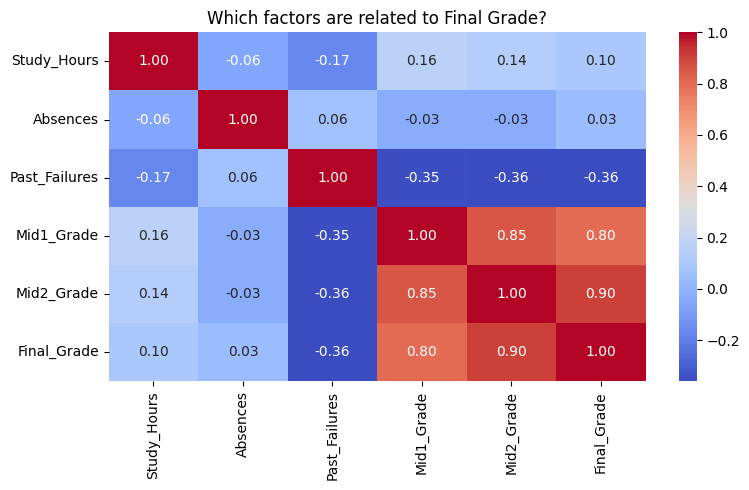

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

print("Basic stats:")
print(df.describe())

print("\nAny missing values?")
print(df.isnull().sum())

# Correlation heatmap
plt.figure(figsize=(8,5))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Which factors are related to Final Grade?")
plt.tight_layout()
plt.savefig('heatmap.png', dpi=150)
plt.show()

In [5]:
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

X = df.drop('Final_Grade', axis=1)
y = df['Final_Grade']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

models = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression':  Ridge(alpha=1.0),
    'Random Forest':     RandomForestRegressor(n_estimators=100, random_state=42)
}

results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    results[name] = {
        'R² Score': round(r2_score(y_test, preds), 3),
        'MAE':      round(mean_absolute_error(y_test, preds), 3),
        'RMSE':     round(np.sqrt(mean_squared_error(y_test, preds)), 3)
    }

results_df = pd.DataFrame(results).T
print(results_df)

                   R² Score    MAE   RMSE
Linear Regression     0.782  1.339  2.113
Ridge Regression      0.782  1.339  2.113
Random Forest         0.871  1.055  1.625


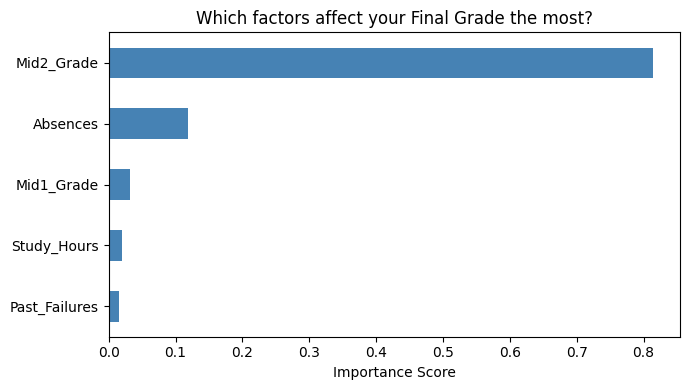

In [6]:
rf_model = models['Random Forest']
importances = pd.Series(rf_model.feature_importances_, index=X.columns)
importances = importances.sort_values(ascending=True)

plt.figure(figsize=(7,4))
importances.plot(kind='barh', color='steelblue')
plt.title("Which factors affect your Final Grade the most?")
plt.xlabel("Importance Score")
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150)
plt.show()

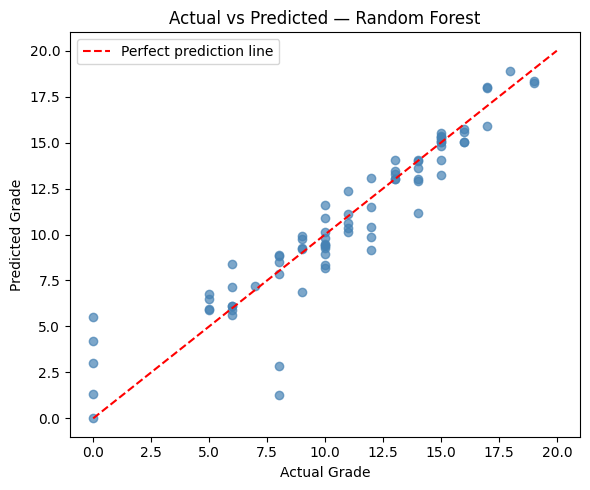

In [7]:
best_preds = models['Random Forest'].predict(X_test)

plt.figure(figsize=(6,5))
plt.scatter(y_test, best_preds, alpha=0.7, color='steelblue')
plt.plot([0,20],[0,20], 'r--', label='Perfect prediction line')
plt.xlabel("Actual Grade")
plt.ylabel("Predicted Grade")
plt.title("Actual vs Predicted — Random Forest")
plt.legend()
plt.tight_layout()
plt.savefig('actual_vs_predicted.png', dpi=150)
plt.show()

In [10]:
new_student = pd.DataFrame({
    'Study_Hours':  [1],
    'Absences':     [27],
    'Past_Failures':[3],
    'Mid1_Grade':   [4],
    'Mid2_Grade':   [3]
})

predicted_grade = models['Random Forest'].predict(new_student)[0]
print(f"Predicted Final Grade: {predicted_grade:.1f} / 20")

if predicted_grade >= 14:
    print("Status: ✅ PASS — performing well!")
elif predicted_grade >= 10:
    print("Status: ⚠️ AT RISK — needs improvement")
else:
    print("Status: ❌ HIGH RISK — needs urgent support")

Predicted Final Grade: 5.2 / 20
Status: ❌ HIGH RISK — needs urgent support
